# Análisis Exploratorio de Datos (EDA)
## Features extraídas desde representaciones topológicas (GSP y TSP)

Este notebook explora y caracteriza los datasets de features generados a
partir de las representaciones topológicas **Graph Signal Processing (GSP)**
y **Topological Signal Processing (TSP)**. A diferencia de los notebooks 04
y 05 (técnicas tiempo-frecuencia: STFT, CWT, SST, WPD), estas dos técnicas
no producen features por canal — entregan un conjunto reducido de 4 features
**agregadas globalmente** sobre el arreglo de 14 electrodos:

- `spatial_abs` — magnitud espacial absoluta
- `spatial_rel` — magnitud espacial relativa
- `entropy` — entropía de la representación topológica
- `cog` — centro de gravedad (espacial o espectral, según la técnica)

El objetivo es el mismo que en el notebook 04: verificar integridad,
visualizar distribuciones, y detectar patrones o problemas que informen
si conviene avanzar con la integración de estas features en la
clasificación. Dada la diferencia estructural (4 features agregadas vs. 56
features por canal), el análisis se adapta — no hay matriz de correlación
*entre canales*, pero sí tiene sentido analizar la correlación *entre las 4
features* de cada técnica, y la relación entre GSP y TSP entre sí.

In [1]:
# --- Celda 1: Importaciones y Carga de Datos ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import mannwhitneyu

# Configuración visual
sns.set_theme(style="whitegrid")
colors = ["#4C72B0", "#DD8452"]  # Azul (Abiertos) y Naranja (Cerrados) para mantener consistencia
sns.set_palette(sns.color_palette(colors))

# ── Rutas ────────────────────────────────────────────────────────────────
GSP_PATH = './data/features/features_gsp.csv'
TSP_PATH = './data/features/features_tsp.csv'

for p in [GSP_PATH, TSP_PATH]:
    if not Path(p).exists():
        raise FileNotFoundError(f"Archivo no encontrado: {p}")

# Cargar los features topológicos
df_gsp = pd.read_csv(GSP_PATH)
df_tsp = pd.read_csv(TSP_PATH)

# Mapear etiquetas para mejor visualización
label_map = {0: 'Ojos Abiertos (0)', 1: 'Ojos Cerrados (1)'}
df_gsp['Estado'] = df_gsp['label'].map(label_map)
df_tsp['Estado'] = df_tsp['label'].map(label_map)

# ── Configuración ────────────────────────────────────────────────────────
GSP_FEATURES = ['GSP_spatial_abs', 'GSP_spatial_rel', 'GSP_entropy', 'GSP_cog']
TSP_FEATURES = ['TSP_spatial_abs', 'TSP_spatial_rel', 'TSP_entropy', 'TSP_cog']
TOPO_TECHNIQUES = [('GSP', df_gsp, GSP_FEATURES), ('TSP', df_tsp, TSP_FEATURES)]

print(f"Dataset GSP cargado: {df_gsp.shape}  |  NaN: {df_gsp[GSP_FEATURES].isnull().sum().sum()}")
print(f"Dataset TSP cargado: {df_tsp.shape}  |  NaN: {df_tsp[TSP_FEATURES].isnull().sum().sum()}")
print(f"\nDistribución de clases (GSP):\n{df_gsp['Estado'].value_counts()}")


Dataset GSP cargado: (231, 6)  |  NaN: 0
Dataset TSP cargado: (231, 6)  |  NaN: 0

Distribución de clases (GSP):
Estado
Ojos Abiertos (0)    125
Ojos Cerrados (1)    106
Name: count, dtype: int64


## Sección 1: Validación básica

Igual que en el notebook 04, antes de cualquier análisis se verifica la
integridad estructural: ausencia de NaN, balance de clases, y — punto
crítico para que cualquier comparación entre GSP, TSP y las técnicas TF sea
válida más adelante — que las etiquetas sean idénticas entre todos los
datasets de features del proyecto (mismas 231 ventanas, mismo orden).

In [2]:
print("=" * 60)
print("BALANCE DE CLASES — GSP y TSP")
print("=" * 60)

for name, df, _ in TOPO_TECHNIQUES:
    counts = df['label'].value_counts().sort_index()
    total = len(df)
    print(f"\n{name}:")
    for cls, n in counts.items():
        estado = "Ojos abiertos" if cls == 0 else "Ojos cerrados"
        print(f"  Clase {cls} ({estado}): {n:3d} ventanas  ({100*n/total:.1f}%)")

# ¿Etiquetas idénticas entre GSP y TSP?
etiquetas_identicas_topo = (df_gsp['label'].values == df_tsp['label'].values).all()
print(f"\n¿Etiquetas idénticas entre GSP y TSP? {'SI' if etiquetas_identicas_topo else 'NO'}")

# ── Comparación contra las técnicas TF (si los CSV están disponibles) ─────
# Esto verifica que las 231 ventanas y sus etiquetas sean consistentes con
# el resto del pipeline (notebooks 04/05), condición necesaria para poder
# comparar GSP/TSP contra STFT/CWT/SST/WPD más adelante.
TF_PATH = './data/features/features_stft.csv'
if Path(TF_PATH).exists():
    df_tf_check = pd.read_csv(TF_PATH)
    mismo_n = len(df_tf_check) == len(df_gsp) == len(df_tsp)
    mismas_labels = (
        mismo_n
        and (df_tf_check['label'].values == df_gsp['label'].values).all()
        and (df_tf_check['label'].values == df_tsp['label'].values).all()
    )
    print(f"¿Mismo N° de ventanas que STFT (referencia TF)? {'SI' if mismo_n else 'NO'} "
          f"(TF={len(df_tf_check)}, GSP={len(df_gsp)}, TSP={len(df_tsp)})")
    print(f"¿Etiquetas idénticas a STFT? {'SI' if mismas_labels else 'NO'}")
else:
    print("(No se encontró features_stft.csv en esta ejecución — "
          "se omite la verificación cruzada contra técnicas TF)")


BALANCE DE CLASES — GSP y TSP

GSP:
  Clase 0 (Ojos abiertos): 125 ventanas  (54.1%)
  Clase 1 (Ojos cerrados): 106 ventanas  (45.9%)

TSP:
  Clase 0 (Ojos abiertos): 125 ventanas  (54.1%)
  Clase 1 (Ojos cerrados): 106 ventanas  (45.9%)

¿Etiquetas idénticas entre GSP y TSP? SI
¿Mismo N° de ventanas que STFT (referencia TF)? SI (TF=231, GSP=231, TSP=231)
¿Etiquetas idénticas a STFT? SI


### Estadísticas descriptivas por feature y clase

A diferencia del notebook 04 (donde esto se desglosaba por canal), acá las
4 features ya son agregados globales, así que la tabla es compacta: una
fila por feature, comparando media y desviación estándar entre las dos
clases para GSP y TSP.

In [3]:
def tabla_descriptiva(df, features, nombre):
    rows = []
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    for feat in features:
        rows.append({
            'Feature': feat,
            'Clase 0 media': g0[feat].mean(),
            'Clase 1 media': g1[feat].mean(),
            'Clase 0 std':   g0[feat].std(),
            'Clase 1 std':   g1[feat].std(),
        })
    tabla = pd.DataFrame(rows).set_index('Feature')
    print(f"── {nombre} ──")
    print(tabla.to_string(float_format=lambda x: f"{x:.5f}"))
    print()
    return tabla

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS — GSP y TSP")
print("=" * 70)

tabla_gsp = tabla_descriptiva(df_gsp, GSP_FEATURES, "GSP")
tabla_tsp = tabla_descriptiva(df_tsp, TSP_FEATURES, "TSP")


ESTADÍSTICAS DESCRIPTIVAS — GSP y TSP
── GSP ──
                 Clase 0 media  Clase 1 media  Clase 0 std  Clase 1 std
Feature                                                                
GSP_spatial_abs        3.41766        3.39512      1.78605      1.20823
GSP_spatial_rel        0.37531        0.37879      0.01275      0.00834
GSP_entropy            0.94357        0.94103      0.00891      0.00593
GSP_cog                0.36238        0.35775      0.01522      0.00981

── TSP ──
                 Clase 0 media  Clase 1 media  Clase 0 std  Clase 1 std
Feature                                                                
TSP_spatial_abs        0.94255        0.95664      0.26628      0.23964
TSP_spatial_rel        0.15523        0.16045      0.01675      0.01318
TSP_entropy            0.99704        0.99812      0.00239      0.00119
TSP_cog                2.53391        2.49999      0.10043      0.07745



## Sección 2: Distribuciones por clase

Boxplots de las 4 features de cada técnica, separados por estado ocular,
con test de Mann-Whitney U (sin corrección por comparaciones múltiples en
esta etapa exploratoria — la corrección formal se aplica en el notebook 05b)
como primera referencia de separabilidad.

In [4]:
# --- Celda 2: Motor de Visualización y Test Estadístico ---

def plot_topological_features(df, features, title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        
        # Generar Boxplot
        sns.boxplot(data=df, x='Estado', y=feat, ax=ax, width=0.5, 
                    boxprops=dict(alpha=0.8), flierprops=dict(marker='o', markersize=4))
        
        # Test estadístico (Mann-Whitney U)
        class_0 = df[df['label'] == 0][feat]
        class_1 = df[df['label'] == 1][feat]
        stat, p_value = mannwhitneyu(class_0, class_1, alternative='two-sided')
        
        # Formatear el título del subplot
        ax.set_title(f"{feat}\n(p-value: {p_value:.2e})", fontsize=12, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("Valor")
        
    plt.suptitle(f'Análisis Exploratorio: {title_prefix}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

>>> Evaluando Separabilidad de Características GSP <<<


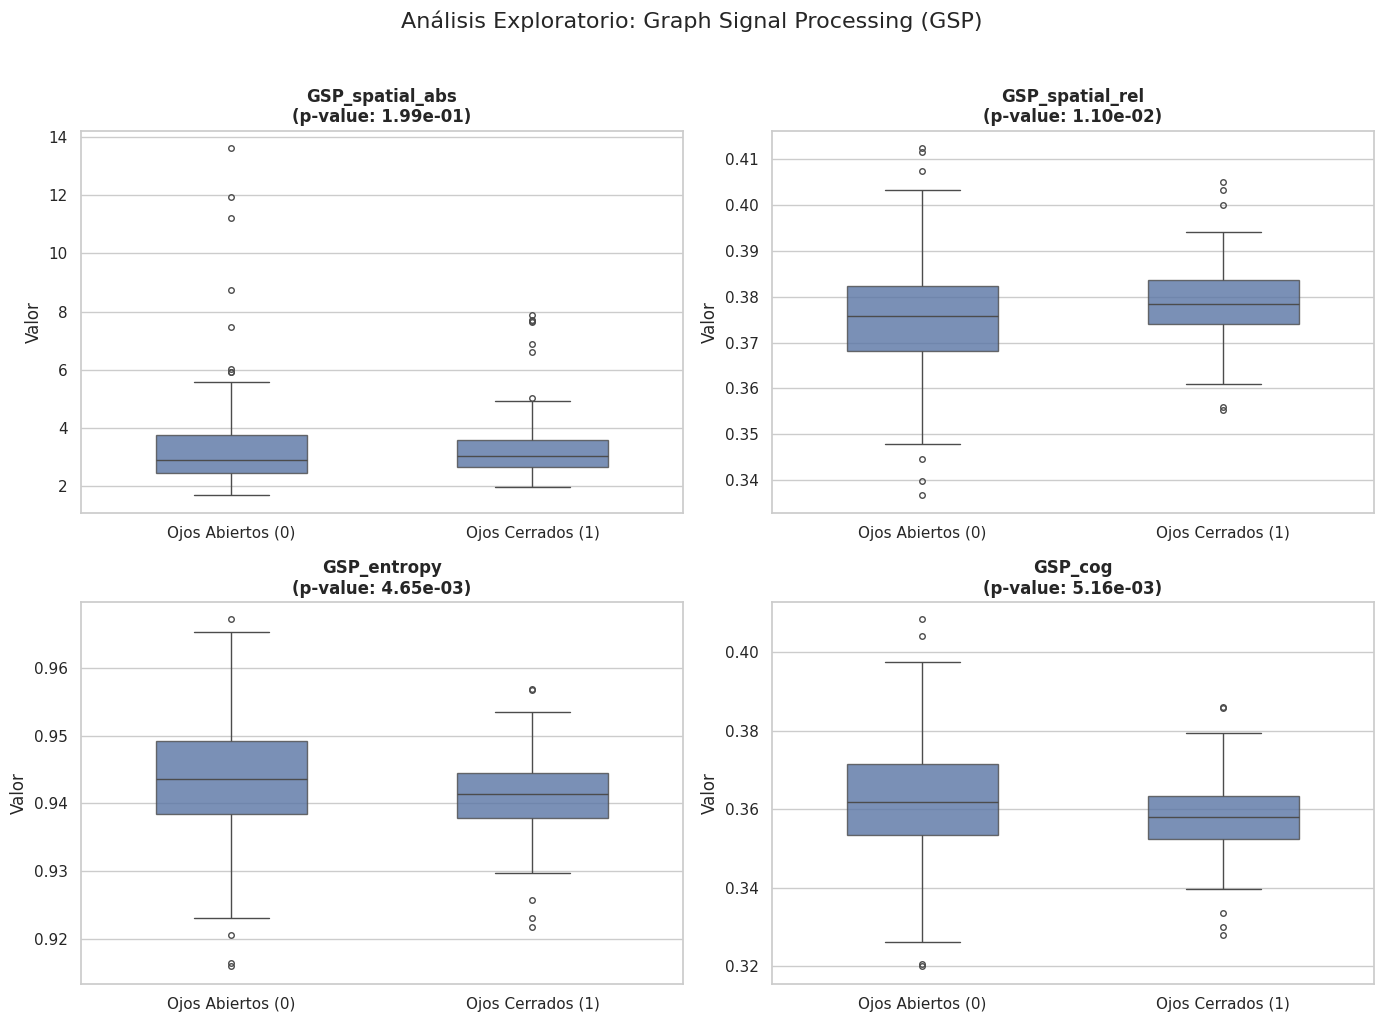

In [5]:
# --- Celda 3: Boxplots GSP ---

gsp_features = [
    'GSP_spatial_abs', 
    'GSP_spatial_rel', 
    'GSP_entropy', 
    'GSP_cog'
]

print(">>> Evaluando Separabilidad de Características GSP <<<")
plot_topological_features(df_gsp, gsp_features, title_prefix="Graph Signal Processing (GSP)")

>>> Evaluando Separabilidad de Características TSP <<<


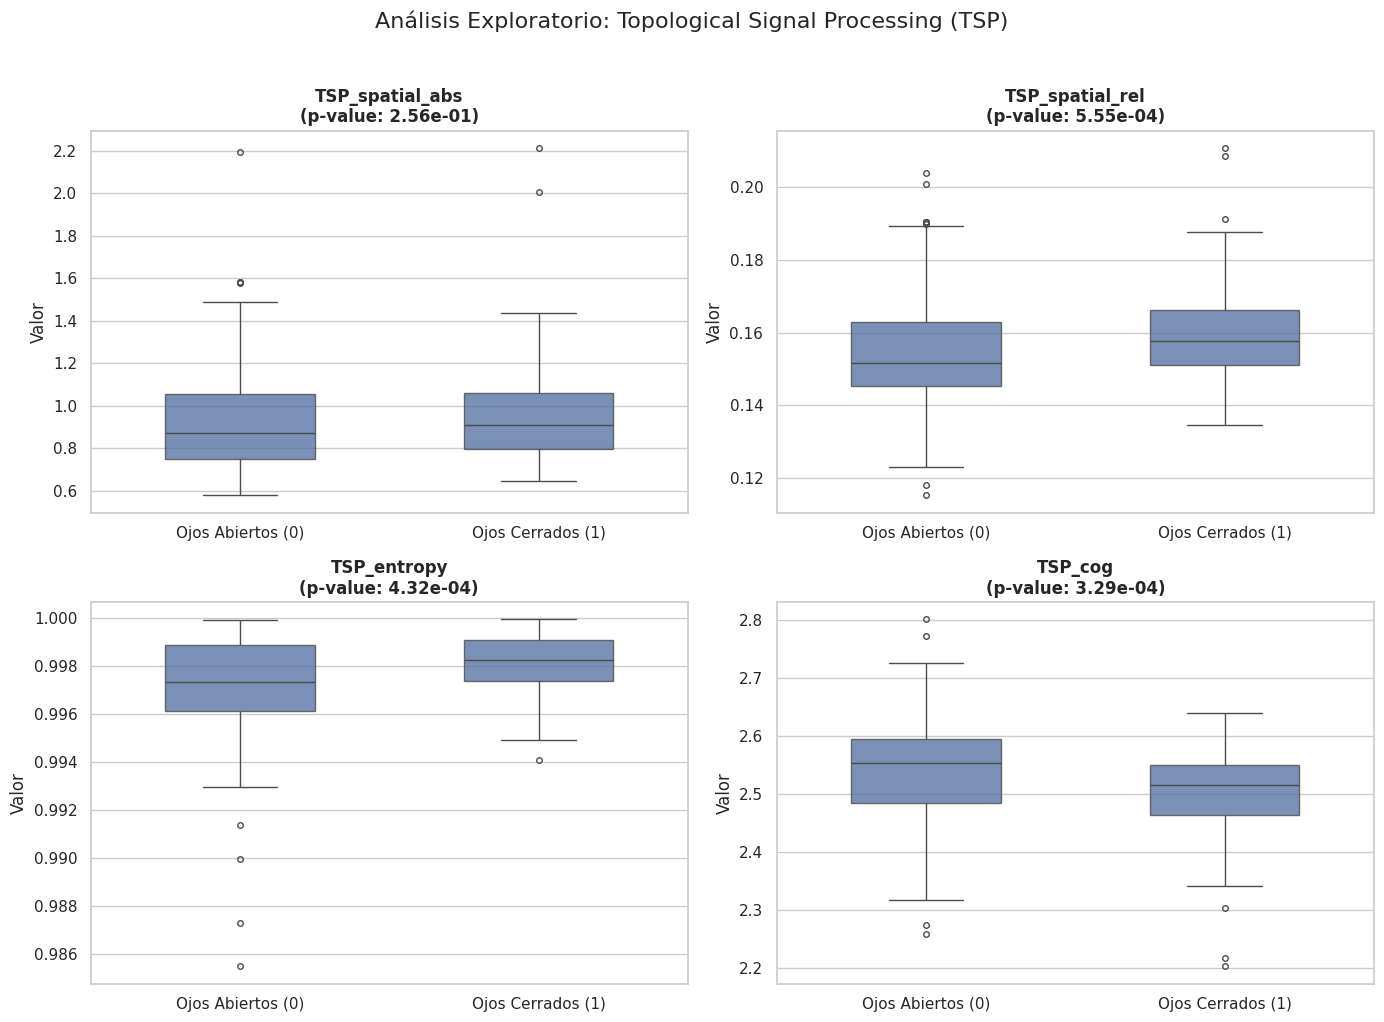

In [6]:
# --- Celda 4: Boxplots TSP ---

tsp_features = [
    'TSP_spatial_abs', 
    'TSP_spatial_rel', 
    'TSP_entropy', 
    'TSP_cog'
]

print(">>> Evaluando Separabilidad de Características TSP <<<")
plot_topological_features(df_tsp, tsp_features, title_prefix="Topological Signal Processing (TSP)")

## Sección 3: Verificación de varianza (coeficiente de variación)

Con solo 4 features por técnica, una sola feature degenerada (casi
constante) representa el 25% del espacio de features — una proporción
mucho más alta que en TF, donde una feature degenerada entre 56
(`entropy` en CWT) era un caso aislado. Por eso este chequeo es,
proporcionalmente, más importante acá.

Se usa el mismo criterio aplicado en el notebook 05: coeficiente de
variación $CV = \text{std} / |\text{media}|$, marcando como degenerada
toda feature con $CV < 2\%$. Como GSP/TSP no tienen dimensión de canal,
el CV se calcula directamente sobre las 231 ventanas, sin promediar entre
canales.

In [7]:
CV_THRESHOLD = 0.02  # CV < 2% -> feature prácticamente constante

print("=" * 70)
print("COEFICIENTE DE VARIACIÓN POR FEATURE — GSP y TSP")
print("=" * 70)

resumen_cv = []
features_degeneradas_topo = []

for name, df, feats in TOPO_TECHNIQUES:
    for feat in feats:
        media = df[feat].mean()
        std   = df[feat].std()
        cv    = std / abs(media) if media != 0 else np.nan
        degenerada = (not np.isnan(cv)) and (cv < CV_THRESHOLD)

        if degenerada:
            features_degeneradas_topo.append((feat, name))

        resumen_cv.append({
            'Técnica':    name,
            'Feature':    feat,
            'Media':      media,
            'Std':        std,
            'CV':         f"{cv:.1%}" if not np.isnan(cv) else "N/A",
            'Degenerada': 'SI' if degenerada else 'No'
        })

df_cv_topo = pd.DataFrame(resumen_cv)
print(df_cv_topo.to_string(index=False))

print(f"\nUmbral: CV < {CV_THRESHOLD:.0%}")
print(f"\nFeatures degeneradas identificadas:")
if features_degeneradas_topo:
    for feat, name in features_degeneradas_topo:
        print(f"  -> {feat} en {name}")
else:
    print("  (ninguna)")


COEFICIENTE DE VARIACIÓN POR FEATURE — GSP y TSP
Técnica         Feature    Media      Std    CV Degenerada
    GSP GSP_spatial_abs 3.407318 1.544794 45.3%         No
    GSP GSP_spatial_rel 0.376910 0.011067  2.9%         No
    GSP     GSP_entropy 0.942404 0.007777  0.8%         SI
    GSP         GSP_cog 0.360257 0.013194  3.7%         No
    TSP TSP_spatial_abs 0.949015 0.253951 26.8%         No
    TSP TSP_spatial_rel 0.157623 0.015405  9.8%         No
    TSP     TSP_entropy 0.997538 0.002007  0.2%         SI
    TSP         TSP_cog 2.518341 0.091999  3.7%         No

Umbral: CV < 2%

Features degeneradas identificadas:
  -> GSP_entropy en GSP
  -> TSP_entropy en TSP


## Sección 4: Correlación entre features (dentro de cada técnica)

Con 4 features por técnica, una matriz de correlación 4×4 es rápida de
inspeccionar y responde una pregunta directa: ¿`spatial_abs` y
`spatial_rel` aportan información redundante? ¿`cog` se mueve junto con
`entropy` o son independientes? Esto es el equivalente reducido del
análisis de correlación entre canales que se hizo en el notebook 04 para
las técnicas TF (donde la matriz era 56×56).

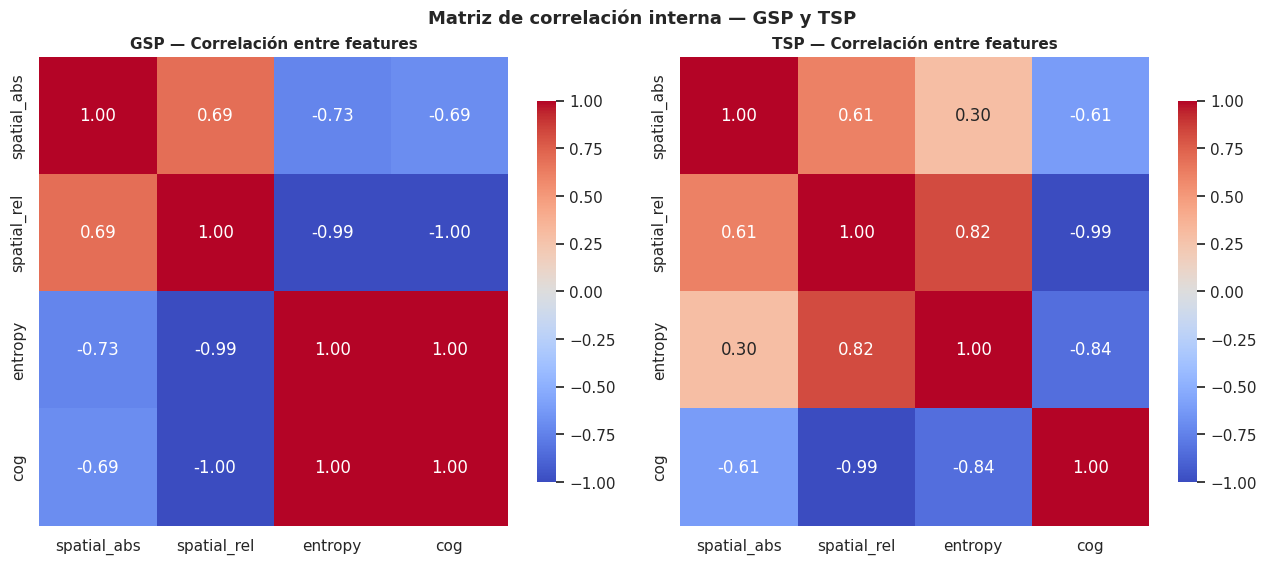

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (name, df, feats) in zip(axes, TOPO_TECHNIQUES):
    corr = df[feats].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                square=True, ax=ax, cbar_kws={'shrink': 0.8},
                xticklabels=[f.split('_', 1)[1] for f in feats],
                yticklabels=[f.split('_', 1)[1] for f in feats])
    ax.set_title(f'{name} — Correlación entre features', fontsize=11, fontweight='bold')

plt.suptitle('Matriz de correlación interna — GSP y TSP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Sección 5: Relación entre GSP y TSP

Antes de decidir si conviene incluir ambas técnicas topológicas en la
clasificación (en vez de solo una), conviene saber si capturan información
similar o complementaria. Se calcula la correlación cruzada entre las 4
features de GSP y las 4 de TSP — si los pares análogos (p. ej. `GSP_cog`
vs `TSP_cog`) están altamente correlacionados, podría ser indicio de
redundancia entre ambas técnicas; si no, sugiere que aportan información
distinta y ambas podrían justificarse en el set final de features.

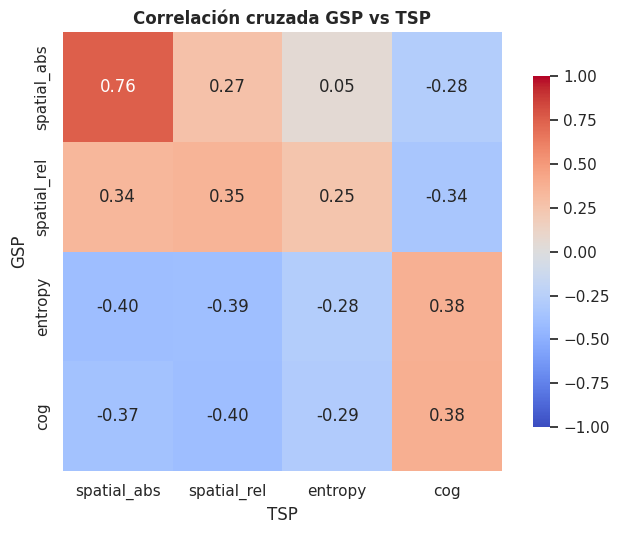

Correlación de pares análogos (misma feature, distinta técnica):
  spatial_abs    r = 0.757
  spatial_rel    r = 0.352
  entropy        r = -0.278
  cog            r = 0.383


In [9]:
# Unir GSP y TSP en un solo DataFrame (mismo orden de ventanas, mismas etiquetas)
df_cross = pd.concat(
    [df_gsp[GSP_FEATURES].reset_index(drop=True),
     df_tsp[TSP_FEATURES].reset_index(drop=True)],
    axis=1
)

corr_cross = df_cross.corr().loc[GSP_FEATURES, TSP_FEATURES]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_cross, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={'shrink': 0.8},
            xticklabels=[f.split('_', 1)[1] for f in TSP_FEATURES],
            yticklabels=[f.split('_', 1)[1] for f in GSP_FEATURES])
ax.set_xlabel('TSP')
ax.set_ylabel('GSP')
ax.set_title('Correlación cruzada GSP vs TSP', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlación de pares análogos (misma feature, distinta técnica):")
for feat_suffix in ['spatial_abs', 'spatial_rel', 'entropy', 'cog']:
    gsp_col = f'GSP_{feat_suffix}'
    tsp_col = f'TSP_{feat_suffix}'
    r = df_cross[gsp_col].corr(df_cross[tsp_col])
    print(f"  {feat_suffix:<14} r = {r:.3f}")


## Resumen de lo realizado en este notebook

Este notebook cubrió, para las features topológicas GSP y TSP:

1. **Validación estructural**: shape, NaN, balance de clases, y
   consistencia de etiquetas entre GSP, TSP y (si está disponible) las
   técnicas TF del resto del pipeline.
2. **Estadísticas descriptivas** por feature y clase (media, std).
3. **Distribuciones por clase** (boxplots) con test de Mann-Whitney U
   exploratorio, sin corrección por comparaciones múltiples.
4. **Coeficiente de variación** por feature, para detectar posibles
   features degeneradas — relevante dado que aquí cada feature representa
   el 25% del espacio total (vs. ~1.8% en TF).
5. **Correlación interna** entre las 4 features de cada técnica.
6. **Correlación cruzada** entre GSP y TSP, para evaluar si ambas técnicas
   aportan información redundante o complementaria.

Como aún no se ha ejecutado este notebook contra los datos reales, no se
incluyen observaciones ni conclusiones sobre los resultados — los gráficos
y tablas de arriba están listos para ejecutarse y leerse, pero su
interpretación queda pendiente hasta correrlos.

### Lo que queda pendiente

Al igual que el notebook 04 fue complementado por el 05 (métricas
estadísticas formales: Cohen's $d$, FDR, Mutual Information, con
corrección de Bonferroni), este notebook 04b tiene su contraparte en el
**notebook 05b**, que aplica esas mismas métricas a GSP y TSP, y agrega
una comparación cuantitativa contra las cuatro técnicas TF (STFT, CWT,
SST, WPD) ya evaluadas en el notebook 05 — para responder, con números y
no solo con inspección visual, si vale la pena incorporar las features
topológicas a la etapa de clasificación.